# AI CV Personality Analyzer
## 05 - Model Evaluation

### Objective

This notebook evaluates the final Machine Learning models trained
for the Big Five personality traits.

The five personality traits are:

- O — Openness
- C — Conscientiousness
- E — Extraversion
- A — Agreeableness
- N — Neuroticism

### Evaluation Strategy

The final models were trained using the combined training and
validation datasets.

The test dataset was kept completely separate during model
selection and final training.

Therefore, the test dataset will be used here only for the final
unbiased evaluation.

### Evaluation Metrics

The models will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC where applicable
- Confusion Matrix

The results will also be saved for use by the final application
and project documentation.

## 1. Import Required Libraries

The following libraries are required for:

- Loading feature matrices
- Loading target labels
- Loading trained models
- Calculating evaluation metrics
- Creating confusion matrices
- Creating performance visualizations
- Saving evaluation results

In [1]:
# Import os for file and directory operations
import os

# Import joblib for loading trained Machine Learning models
import joblib

# Import NumPy for numerical operations
import numpy as np

# Import pandas for DataFrame operations
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import sparse matrix loader
from scipy.sparse import load_npz

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths

The final trained personality models and test feature matrix
were generated during the previous notebooks.

We will load these saved artifacts from the `models` directory.

In [2]:
# Define the models directory
MODELS_DIR = "../models"

# Define the test feature matrix path
X_TEST_PATH = os.path.join(
    MODELS_DIR,
    "X_test.npz"
)

# Define the test target path
Y_TEST_PATH = os.path.join(
    MODELS_DIR,
    "y_test.parquet"
)

# Define the five Big Five personality traits
TARGET_COLUMNS = [
    "O",
    "C",
    "E",
    "A",
    "N"
]

# Define readable names for the personality traits
TRAIT_NAMES = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism"
}

print("Project paths configured successfully.")

Project paths configured successfully.


## 3. Load the Untouched Test Dataset

The test dataset contains:

- 494 records
- 35,007 features

This dataset was not used during model selection or final model training.

It will now be used only to measure the final performance of
the personality prediction models.

In [3]:
# Load the test feature matrix
X_test = load_npz(X_TEST_PATH)

# Load the test personality labels
y_test = pd.read_parquet(Y_TEST_PATH)

# Display the test dataset information
print("Test Dataset")
print("-" * 50)

print("Feature Matrix :", X_test.shape)
print("Target Matrix  :", y_test.shape)

print("\nTarget Columns:")
print(list(y_test.columns))

Test Dataset
--------------------------------------------------
Feature Matrix : (494, 35007)
Target Matrix  : (494, 5)

Target Columns:
['O', 'C', 'E', 'A', 'N']


## 4. Verify Test Data

Before evaluation, verify that:

- Feature and target row counts match.
- All Big Five personality targets exist.
- Each target contains both binary classes.
- No missing target values exist.

These checks ensure that the final evaluation is performed
on valid test data.

In [4]:
# Verify the number of test feature rows
assert X_test.shape[0] == len(y_test)

# Verify all five personality traits exist
for trait in TARGET_COLUMNS:

    assert trait in y_test.columns

# Check for missing values
missing_values = y_test[TARGET_COLUMNS].isnull().sum()

print("Missing Values")
print("-" * 50)
print(missing_values)

# Verify that each personality trait contains both classes
for trait in TARGET_COLUMNS:

    unique_values = sorted(
        y_test[trait].astype(int).unique()
    )

    print(
        f"{trait} ({TRAIT_NAMES[trait]}): "
        f"{unique_values}"
    )

print("\nTest data verification completed successfully.")

Missing Values
--------------------------------------------------
O    0
C    0
E    0
A    0
N    0
dtype: int64
O (Openness): [0, 1]
C (Conscientiousness): [0, 1]
E (Extraversion): [0, 1]
A (Agreeableness): [0, 1]
N (Neuroticism): [0, 1]

Test data verification completed successfully.


## 5. Load Final Personality Models

The final models were selected during Notebook 04.

One model is maintained for each Big Five personality trait:

- `personality_model_O.pkl`
- `personality_model_C.pkl`
- `personality_model_E.pkl`
- `personality_model_A.pkl`
- `personality_model_N.pkl`

These models were trained using the combined training and
validation datasets.

In [5]:
# Dictionary to store the loaded final models
final_models = {}

# Load one model for each personality trait
for trait in TARGET_COLUMNS:

    # Build the model file path
    model_path = os.path.join(
        MODELS_DIR,
        f"personality_model_{trait}.pkl"
    )

    # Verify that the model file exists
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Model file not found: {model_path}"
        )

    # Load the trained model
    final_models[trait] = joblib.load(
        model_path
    )

    print(
        f"{trait} - {TRAIT_NAMES[trait]} "
        f"model loaded successfully."
    )

print("\nAll final personality models loaded.")

O - Openness model loaded successfully.
C - Conscientiousness model loaded successfully.
E - Extraversion model loaded successfully.
A - Agreeableness model loaded successfully.
N - Neuroticism model loaded successfully.

All final personality models loaded.


## 6. Generate Test Predictions

Each final model will predict its corresponding personality trait
on the untouched test dataset.

The predictions will be stored for later evaluation.

No model training or parameter selection will be performed here.

In [6]:
# Dictionary to store predictions
test_predictions = {}

# Dictionary to store prediction scores
test_scores = {}

# Generate predictions for every personality trait
for trait in TARGET_COLUMNS:

    # Get the trained model
    model = final_models[trait]

    # Generate binary predictions
    predictions = model.predict(
        X_test
    )

    # Store predictions
    test_predictions[trait] = predictions

    # Store decision/probability scores when available
    if hasattr(model, "decision_function"):

        test_scores[trait] = model.decision_function(
            X_test
        )

    elif hasattr(model, "predict_proba"):

        test_scores[trait] = model.predict_proba(
            X_test
        )[:, 1]

    else:

        test_scores[trait] = None

    print(
        f"{trait} - {TRAIT_NAMES[trait]} "
        f"predictions generated."
    )

# Convert predictions into a DataFrame
test_predictions_df = pd.DataFrame(
    test_predictions
)

print("\nPrediction Matrix:")
print(test_predictions_df.shape)

display(test_predictions_df.head())

O - Openness predictions generated.
C - Conscientiousness predictions generated.
E - Extraversion predictions generated.
A - Agreeableness predictions generated.
N - Neuroticism predictions generated.

Prediction Matrix:
(494, 5)


,O,C,E,A,N
0,0,1,1,1,1
1,1,1,1,1,1
2,0,1,1,1,0
3,0,0,1,1,1
4,0,1,1,1,0


## 7. Calculate Final Classification Metrics

For every personality trait, calculate:

### Accuracy

Percentage of correctly classified records.

### Precision

Measures how many predicted positive records were actually positive.

### Recall

Measures how many actual positive records were correctly identified.

### F1-score

Harmonic mean of precision and recall.

### ROC-AUC

Measures the model's ability to distinguish between the two classes.

F1-score and ROC-AUC provide additional information beyond accuracy.

In [7]:
# Store final evaluation results
evaluation_results = []

# Evaluate each personality trait
for trait in TARGET_COLUMNS:

    # Convert actual labels to integers
    y_true = y_test[trait].astype(int)

    # Get model predictions
    y_pred = test_predictions[trait]

    # Calculate accuracy
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    # Calculate precision
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Calculate recall
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Calculate F1-score
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Calculate ROC-AUC when a score is available
    if test_scores[trait] is not None:

        auc = roc_auc_score(
            y_true,
            test_scores[trait]
        )

    else:

        auc = np.nan

    # Store the evaluation results
    evaluation_results.append({
        "Trait": trait,
        "Personality": TRAIT_NAMES[trait],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

# Create evaluation DataFrame
evaluation_results_df = pd.DataFrame(
    evaluation_results
)

# Display the final results
display(evaluation_results_df)

,Trait,Personality,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,O,Openness,0.670040,0.667883,0.717647,0.691871,0.694150
1,C,Conscientiousness,0.562753,0.553459,0.704000,0.619718,0.582738
2,E,Extraversion,0.576923,0.559896,0.843137,0.672926,0.600394
3,A,Agreeableness,0.566802,0.557339,0.920455,0.694286,0.593956
4,N,Neuroticism,0.572874,0.569231,0.599190,0.583826,0.588110


## 8. Final Performance Summary

The table above represents the final performance of the five
personality prediction models on the completely untouched
test dataset.

These scores are the main Machine Learning performance results
that should be reported in the project documentation.

In [8]:
# Calculate average performance across all five traits
average_metrics = {
    "Accuracy": evaluation_results_df["Accuracy"].mean(),
    "Precision": evaluation_results_df["Precision"].mean(),
    "Recall": evaluation_results_df["Recall"].mean(),
    "F1 Score": evaluation_results_df["F1 Score"].mean(),
    "ROC-AUC": evaluation_results_df["ROC-AUC"].mean()
}

# Convert the average metrics into a DataFrame
average_metrics_df = pd.DataFrame(
    [average_metrics]
)

print("Average Performance Across Big Five Traits")
print("-" * 60)

display(
    average_metrics_df.round(4)
)

Average Performance Across Big Five Traits
------------------------------------------------------------


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.5899,0.5816,0.7569,0.6525,0.6119


## 9. Classification Reports

Generate a detailed classification report for every personality trait.

The report provides:

- Precision
- Recall
- F1-score
- Support

Support represents the number of actual samples belonging to each class.

In [9]:
# Generate a classification report for each personality trait
for trait in TARGET_COLUMNS:

    # Get actual labels
    y_true = y_test[trait].astype(int)

    # Get predicted labels
    y_pred = test_predictions[trait]

    print("\n" + "=" * 70)
    print(
        f"{trait} - "
        f"{TRAIT_NAMES[trait]} Classification Report"
    )
    print("=" * 70)

    # Generate and display the classification report
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Class 0",
                "Class 1"
            ],
            zero_division=0
        )
    )


O - Openness Classification Report
              precision    recall  f1-score   support

     Class 0       0.67      0.62      0.64       239
     Class 1       0.67      0.72      0.69       255

    accuracy                           0.67       494
   macro avg       0.67      0.67      0.67       494
weighted avg       0.67      0.67      0.67       494


C - Conscientiousness Classification Report
              precision    recall  f1-score   support

     Class 0       0.58      0.42      0.49       244
     Class 1       0.55      0.70      0.62       250

    accuracy                           0.56       494
   macro avg       0.57      0.56      0.55       494
weighted avg       0.57      0.56      0.55       494


E - Extraversion Classification Report
              precision    recall  f1-score   support

     Class 0       0.64      0.29      0.40       239
     Class 1       0.56      0.84      0.67       255

    accuracy                           0.58       494
   macr

## 10. Confusion Matrices

A confusion matrix shows how the model classified the test records.

For each personality trait:

- True Negative
- False Positive
- False Negative
- True Positive

will be displayed.

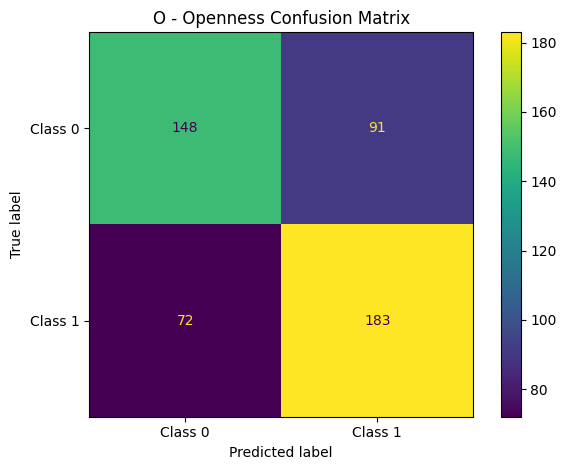

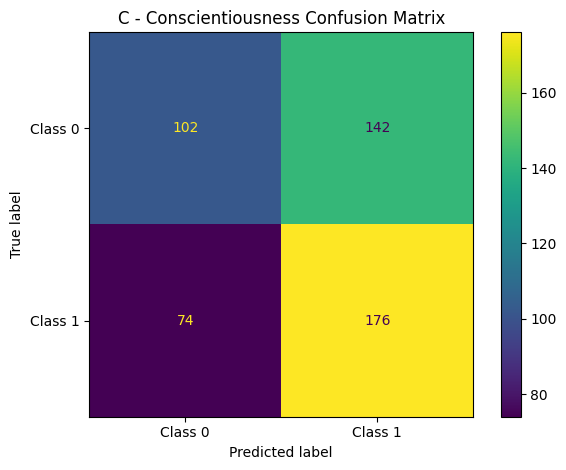

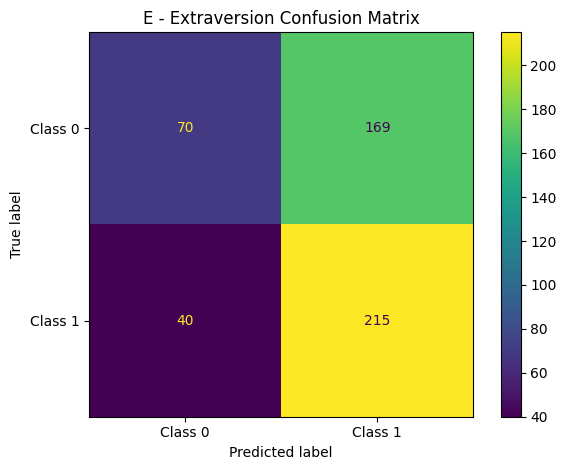

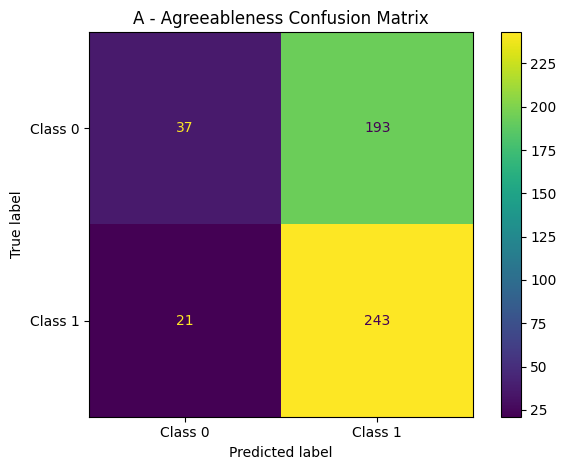

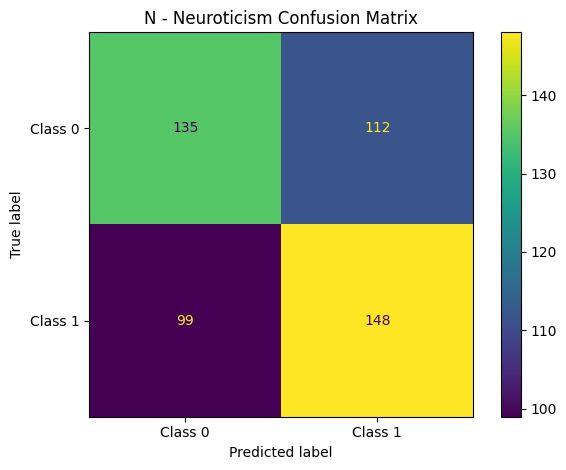

In [10]:
# Create one confusion matrix for each personality trait
for trait in TARGET_COLUMNS:

    # Get actual labels
    y_true = y_test[trait].astype(int)

    # Get predictions
    y_pred = test_predictions[trait]

    # Calculate confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Create the confusion matrix display
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Class 0",
            "Class 1"
        ]
    )

    # Create the plot
    display.plot()

    # Add title
    plt.title(
        f"{trait} - "
        f"{TRAIT_NAMES[trait]} Confusion Matrix"
    )

    # Improve layout
    plt.tight_layout()

    # Display the chart
    plt.show()

## 11. Compare Personality Trait Performance

The following visualization compares the final F1-score of
all five personality prediction models.

A higher F1-score indicates a better balance between precision
and recall.

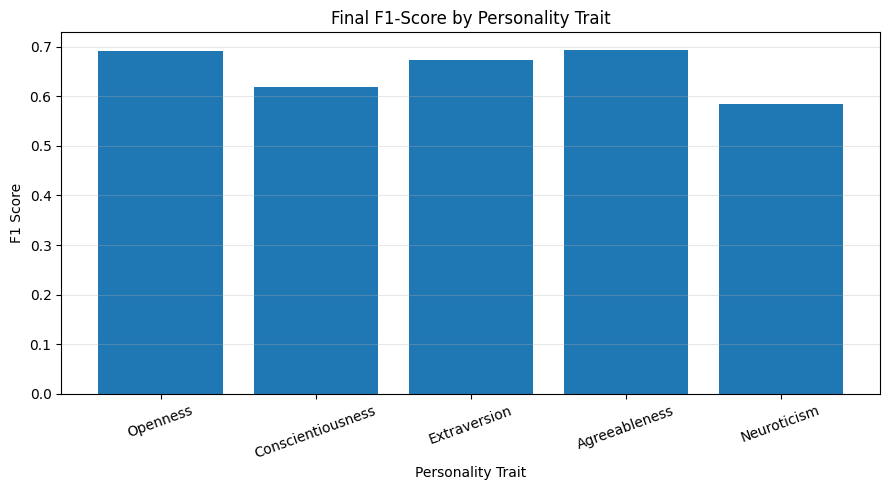

In [11]:
# Create the F1-score comparison chart
plt.figure(figsize=(9, 5))

plt.bar(
    evaluation_results_df["Personality"],
    evaluation_results_df["F1 Score"]
)

# Add chart title
plt.title(
    "Final F1-Score by Personality Trait"
)

# Add axis labels
plt.xlabel(
    "Personality Trait"
)

plt.ylabel(
    "F1 Score"
)

# Rotate labels for readability
plt.xticks(
    rotation=20
)

# Add grid for easier comparison
plt.grid(
    axis="y",
    alpha=0.3
)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

## 12. Compare All Evaluation Metrics

Compare accuracy, precision, recall, and F1-score across
the five personality traits.

This provides an overall view of model performance.

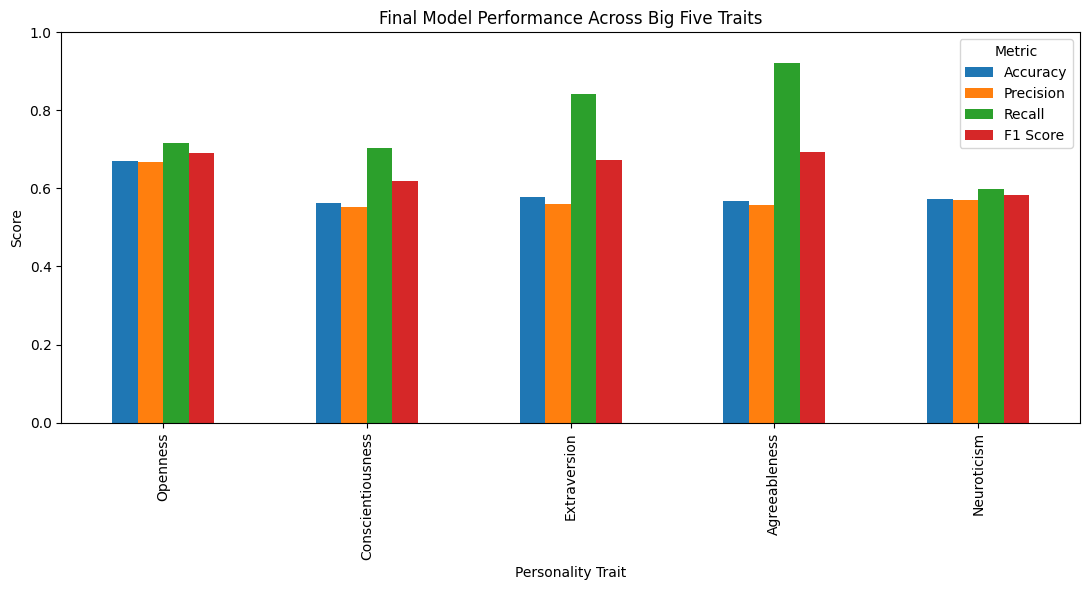

In [12]:
# Select metrics for visualization
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

# Create a copy containing only the required metrics
metrics_df = evaluation_results_df[
    ["Personality"] + metrics_to_plot
]

# Set personality as the DataFrame index
metrics_df = metrics_df.set_index(
    "Personality"
)

# Create the comparison chart
metrics_df.plot(
    kind="bar",
    figsize=(11, 6)
)

# Add title
plt.title(
    "Final Model Performance Across Big Five Traits"
)

# Add axis labels
plt.xlabel(
    "Personality Trait"
)

plt.ylabel(
    "Score"
)

# Keep score range consistent
plt.ylim(
    0,
    1
)

# Display legend
plt.legend(
    title="Metric"
)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

## 13. Identify Strongest and Weakest Personality Models

Identify the personality trait with:

- Highest F1-score
- Lowest F1-score

This helps understand where the system performs strongest
and where further improvement may be required.

In [13]:
# Find the trait with the highest F1-score
best_trait_row = evaluation_results_df.loc[
    evaluation_results_df["F1 Score"].idxmax()
]

# Find the trait with the lowest F1-score
weakest_trait_row = evaluation_results_df.loc[
    evaluation_results_df["F1 Score"].idxmin()
]

print("Best Performing Trait")
print("-" * 50)

print(
    f"{best_trait_row['Trait']} - "
    f"{best_trait_row['Personality']}"
)

print(
    f"F1 Score: "
    f"{best_trait_row['F1 Score']:.4f}"
)

print("\nWeakest Performing Trait")
print("-" * 50)

print(
    f"{weakest_trait_row['Trait']} - "
    f"{weakest_trait_row['Personality']}"
)

print(
    f"F1 Score: "
    f"{weakest_trait_row['F1 Score']:.4f}"
)

Best Performing Trait
--------------------------------------------------
A - Agreeableness
F1 Score: 0.6943

Weakest Performing Trait
--------------------------------------------------
N - Neuroticism
F1 Score: 0.5838


## 14. Save Final Evaluation Results

Save the final test-set evaluation results.

These files will be useful for:

- Project documentation
- README performance section
- Model analysis
- Future application development

In [14]:
# Save detailed evaluation results
evaluation_results_path = os.path.join(
    MODELS_DIR,
    "final_evaluation_results.csv"
)

evaluation_results_df.to_csv(
    evaluation_results_path,
    index=False
)

# Save average performance
average_metrics_path = os.path.join(
    MODELS_DIR,
    "average_model_performance.csv"
)

average_metrics_df.to_csv(
    average_metrics_path,
    index=False
)

# Save predictions for future analysis
predictions_path = os.path.join(
    MODELS_DIR,
    "test_predictions.csv"
)

test_predictions_df.to_csv(
    predictions_path,
    index=False
)

print(
    "Final evaluation results saved successfully."
)

print(
    f"\nSaved:\n"
    f"- {evaluation_results_path}\n"
    f"- {average_metrics_path}\n"
    f"- {predictions_path}"
)

Final evaluation results saved successfully.

Saved:
- ../models\final_evaluation_results.csv
- ../models\average_model_performance.csv
- ../models\test_predictions.csv


## 15. Final Evaluation Verification

Verify that the evaluation results contain:

- All five personality traits
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The evaluation pipeline is considered complete when all five
traits have valid results.

In [15]:
# Verify that all five personality traits are present
assert set(
    evaluation_results_df["Trait"]
) == set(TARGET_COLUMNS)


# Define the evaluation metrics that must be available
required_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]


# Verify that every required metric exists
for metric in required_metrics:

    assert metric in evaluation_results_df.columns


# Verify that exactly five personality traits were evaluated
assert len(evaluation_results_df) == 5


# If all checks pass, print a success message
print("Evaluation verification successful.")


# ============================================================
# DISPLAY FINAL EVALUATION RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL EVALUATION RESULTS")
print("=" * 80)


# Round numerical values for cleaner output
final_results = evaluation_results_df.copy()

final_results[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
] = final_results[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].round(4)


# Print the final evaluation table
print(final_results.to_string(index=False))


print("\n" + "=" * 80)
print("FINAL AVERAGE PERFORMANCE")
print("=" * 80)


# Calculate average performance across all five traits
final_average = {
    "Accuracy": evaluation_results_df["Accuracy"].mean(),
    "Precision": evaluation_results_df["Precision"].mean(),
    "Recall": evaluation_results_df["Recall"].mean(),
    "F1 Score": evaluation_results_df["F1 Score"].mean(),
    "ROC-AUC": evaluation_results_df["ROC-AUC"].mean()
}


# Print each average metric
for metric, score in final_average.items():

    print(
        f"{metric:<12}: {score:.4f}"
    )


print("\nFinal model evaluation completed successfully.")

Evaluation verification successful.

FINAL EVALUATION RESULTS
Trait       Personality  Accuracy  Precision  Recall  F1 Score  ROC-AUC
    O          Openness    0.6700     0.6679  0.7176    0.6919   0.6942
    C Conscientiousness    0.5628     0.5535  0.7040    0.6197   0.5827
    E      Extraversion    0.5769     0.5599  0.8431    0.6729   0.6004
    A     Agreeableness    0.5668     0.5573  0.9205    0.6943   0.5940
    N       Neuroticism    0.5729     0.5692  0.5992    0.5838   0.5881

FINAL AVERAGE PERFORMANCE
Accuracy    : 0.5899
Precision   : 0.5816
Recall      : 0.7569
F1 Score    : 0.6525
ROC-AUC     : 0.6119

Final model evaluation completed successfully.


# 16. Final Machine Learning Evaluation Summary

The Big Five personality prediction models have been evaluated
using the completely untouched test dataset.

## Personality Traits Evaluated

- **O — Openness**
- **C — Conscientiousness**
- **E — Extraversion**
- **A — Agreeableness**
- **N — Neuroticism**

## Evaluation Metrics

The final models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## Data Leakage Prevention

The test dataset was not used during:

- Model training
- Hyperparameter selection
- Model selection

The test dataset was used only for final performance evaluation.

## Evaluation Result

The final evaluation results and average performance have been
saved in the `models` directory.

## Machine Learning Pipeline Status

The complete Machine Learning pipeline is now finished:

1. Data Exploration
2. Data Preprocessing
3. Feature Engineering
4. Model Training
5. Model Evaluation

## Next Stage — Dynamic CV Personality Analyzer

The next stage is to connect the trained Machine Learning pipeline
to the application.

The application will dynamically accept a candidate's CV/resume
and:

1. Upload a PDF or DOCX CV.
2. Extract the CV text.
3. Clean and preprocess the extracted text.
4. Generate the same TF-IDF and statistical features used during training.
5. Load the trained Big Five personality models.
6. Predict all five personality traits.
7. Extract relevant skills and career information.
8. Generate a structured personality analysis.
9. Provide career/role matching.
10. Generate a downloadable candidate report.

No static candidate data will be hardcoded into the application.
Each uploaded CV will be processed dynamically.